In [10]:
import pandas as pd
import numpy as np
import pickle
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
from kneed import KneeLocator

# Configurações básicas
nltk.download("stopwords")
stop_words_pt = stopwords.words("portuguese")

# Carregar dados
df_noticias = pd.read_csv("./arquivos/noticias.csv", dtype={"page": "string", "text": "string", "issued": "string"})
df_historico = pd.read_csv("./arquivos/historico.csv", dtype={"userId": "string", "page": "string", "timestampHistory": "string",
                                                     "numberOfClicks": "int", "timeOnPage": "int",
                                                     "scrollPercentage": "float", "pageVisitsCount": "int"})


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\accs9\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
# Converter datas
df_noticias["issued"] = pd.to_datetime(df_noticias["issued"], errors="coerce")
df_historico["timestampHistory"] = pd.to_datetime(df_historico["timestampHistory"], errors="coerce")

# Agregar engajamento por página
df_engajamento = df_historico.groupby("page").agg(
    total_clicks=("numberOfClicks", "sum"),
    total_time=("timeOnPage", "sum"),
    total_scroll=("scrollPercentage", "mean"),
    total_visits=("pageVisitsCount", "sum")
).reset_index().rename(columns={"page": "page"})

# Merge engajamento nas notícias
df_noticias = df_noticias.merge(df_engajamento, on="page", how="left").fillna(0)

# Rank de data (notícias mais recentes)
df_noticias["date_ranking"] = df_noticias["issued"].rank(method="dense", ascending=False).astype("Int64")

# Exibir as primeiras notícias no ranking (top 10 mais recentes)
print("\n Top 10 notícias mais recentes:")
display(df_noticias.sort_values("date_ranking").head(10))



 Top 10 notícias mais recentes:


,page,url,issued,modified,title,body,caption,text,total_clicks,total_time,total_scroll,total_visits,date_ranking
120018,ebd223ab-9d97-429f-bf02-1781477f2653,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:57:16,2022-08-15 02:57:17,Varíola dos macacos: é possível conter o surto...,Vacina contra varíola pode chegar em setembro ...,"O governo anunciou que chegam ao Brasil, em se...",Varíola dos macacos: é possível conter o surto...,31,176205,25.180000,3,1
155137,340f9f0b-98b1-4a18-a339-7bf927198911,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:40:07,2022-08-15 02:40:07,Brad Pitt diz que teve dificuldade em cenas de...,Brad Pitt é dirigido por ex-dublê em comédia c...,Longa reúne estrelas consagradas como Sandra B...,Brad Pitt diz que teve dificuldade em cenas de...,1,15548,6.455000,2,2
100894,292d82a1-5e96-4b3b-8ee7-e696f3aa771c,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:31:41,2022-08-15 02:31:41,'Bichos na Escuta - Salvei o meu cachorro': co...,'Bichos na Escuta - Salvei o meu cachorro': co...,No primeiro episódio de “Bichos na Escuta – Sa...,'Bichos na Escuta - Salvei o meu cachorro': co...,14,99400,20.427500,4,3
178577,78cd9782-3466-4808-a231-41608c2e4d1b,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:24:26,2022-08-15 04:24:25,Lucy Alves teve ajuda de Thaynara OG para trab...,Lucy Alves teve ajuda de Thaynara OG para trab...,"Como a atriz é de João Pessoa, teve que trabal...",Lucy Alves teve ajuda de Thaynara OG para trab...,12,112903,24.880000,8,4
12880,c2fe4ec2-0a35-437b-86f3-f1ce1057fa68,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:21:37,2022-08-15 09:51:50,"Salman Rushdie, alvo de ataque em Nova York, p...","Salman Rushdie, alvo de ataque em Nova York, p...","Há 30 anos, o escritor foi marcado para morrer...","Salman Rushdie, alvo de ataque em Nova York, p...",81,780552,35.452222,9,5
239791,9c764c3a-f9f8-4fb2-b2c4-6331eaeb3dd6,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 02:04:27,2022-08-15 10:59:19,Áudios e vídeos revelam como os criminosos mai...,Áudios e vídeos revelam como os criminosos mai...,Polícia Federal frustrou o plano de fuga de Ma...,Áudios e vídeos revelam como os criminosos mai...,7322,40030687,43.335740,554,6
211444,40908b83-0102-4e6c-9467-58dd76658be0,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 01:46:09,2022-08-15 02:01:47,\nInvestigação revela como uma rede de aviões ...,O Fantástico investiga a ação de aeronaves do ...,"Durante três dias, Sônia Bridi e Paulo Zero ac...",Investigação revela como uma rede de aviões e...,1103,7648450,39.227196,117,7
136990,97897a8d-6c32-47b1-b890-b465a0a24e6c,http://g1.globo.com/rj/regiao-dos-lagos/notici...,2022-08-15 01:45:45,2022-08-15 01:46:01,Preparatório para universidades tem vagas grat...,Casimiro de Abreu (RJ) está com inscrições abe...,"Projeto, que funciona há cindo anos, conta com...",Preparatório para universidades tem vagas grat...,102,332973,47.841250,8,8
28793,9fd6edda-5f28-4d58-a726-89da76b2a948,http://g1.globo.com/fantastico/noticia/2022/08...,2022-08-15 01:28:22,2022-08-15 01:28:23,Celebração em família é presente de Dia dos Pa...,Dia dos Pais: Djavan fala sobre o novo clipe c...,O cantor recebeu Poliana Abritta em um orquidá...,Celebração em família é presente de Dia dos Pa...,572,3163172,43.896923,45,9
71033,4c3d47a1-6f4b-424f-8944-6c227e686c5c,http://g1.globo.com/sp/sao-paulo/noticia/2022/...,2022-08-15 01:15:32,2022-08-15 13:00:10,Conta do Instagram do PM preso por matar o lut...,Conta do PM Henrique Velozo no Instagram\nRepr...,"Policial está preso no Romão Gomes, penitenciá...",Conta do Instagram do PM preso por matar o lut...,16360,82689278,42.498664,1149,10


In [12]:
stopwords_personalizadas = [
    "governo", "diz", "após", "veja", "confira", 
    "segundo", "brasil", "ano", "país", "mil", "nova", "novo"
]


# Vetorização TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words=stopwords_personalizadas,  # aqui a lista personalizada
    ngram_range=(1, 2)  # pega unigrama e bigrama
)

tfidf_matrix = vectorizer.fit_transform(df_noticias["text"])


 Número ideal de clusters: 8


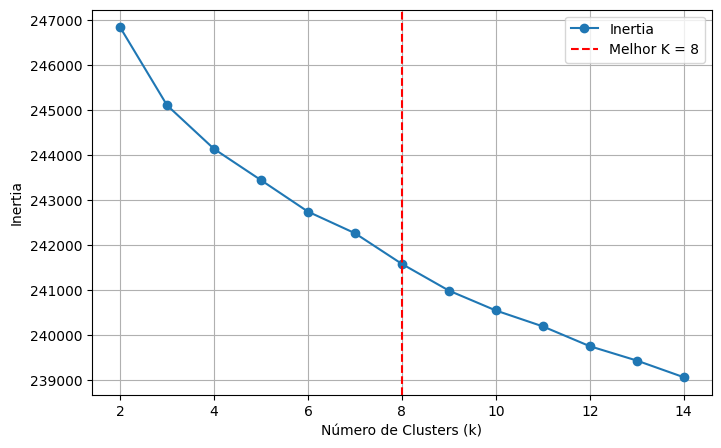

In [ ]:
# Método do cotovelo para encontrar o número ideal de clusters
inertias = []
K = range(2, 15)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    inertias.append(kmeans.inertia_)

knee = KneeLocator(K, inertias, curve="convex", direction="decreasing")
num_clusters = knee.elbow or 10

print(f"\n Número ideal de clusters: {num_clusters}")

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, marker="o", label="Inertia")
plt.axvline(x=num_clusters, linestyle="--", color="r", label=f"Melhor K = {num_clusters}")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inertia")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Definir manualmente os clusters
num_clusters = 8

In [14]:
# Aplicar K-Means e salvar clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_noticias["cluster"] = kmeans.fit_predict(tfidf_matrix)


 Distribuição de notícias por cluster:
   cluster  percentual
0        5    0.372046
1        7    0.267172
2        2    0.158054
3        0    0.062143
4        3    0.058841
5        6    0.058493
6        1    0.014941
7        4    0.008310


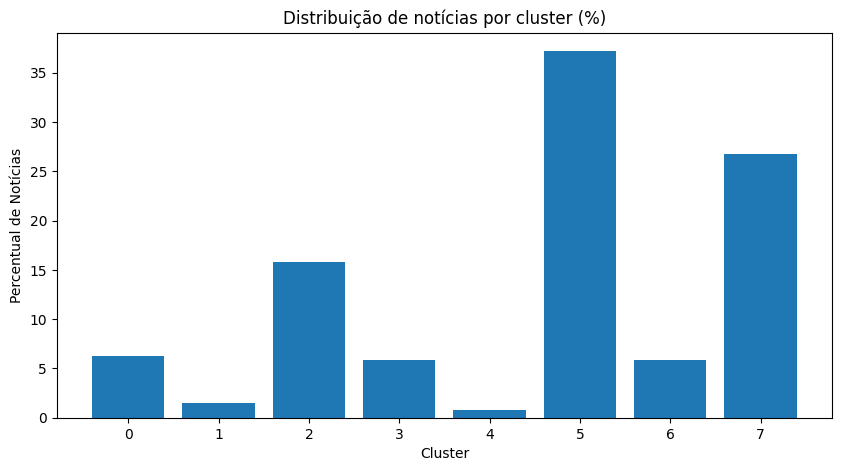


Exemplos por cluster:

Cluster 0:


,cluster,title,caption
18,0,Vídeo mostra que carro de luxo estava em alta ...,"Jonhliane Paiva de Souza, de 30 anos, seguia e..."
23,0,Carreta capota e motorista morre preso às ferr...,"Segundo os bombeiros, acidente ocorreu após us..."
36,0,Trabalhador sofre queimaduras durante incêndio...,"Segundo os bombeiros, chamas começaram em tanq..."
41,0,Amazonas registra quatro mortes no trânsito na...,"Duas das vítimas foram atropeladas, uma caiu d..."
44,0,Homem atropelado por motorista embriagado morr...,Duas crianças também foram atropeladas pelo mo...



Cluster 1:


,cluster,title,caption
152,1,Prefeito de Professor Jamil toma posse; eleiçã...,Ney Novaes (PT) toma posse nesta sexta (1º) co...
360,1,Prefeito e vereadores de São José das Palmeira...,Nelton Brum (PSD) toma posse nesta sexta (1º) ...
994,1,Prefeito e vereadores de Nanuque tomam posse; ...,Gilson Coleta (PROS) toma posse nesta sexta (1...
1002,1,Prefeito e vereadores de Itaquiraí tomam posse...,Thalles Tomazelli (DEM) toma posse nesta sexta...
1004,1,Prefeito e vereadores de Glória de Dourados to...,Aristeu Nantes (Patriota) toma posse nesta sex...



Cluster 2:


...

,cluster,title,caption
3,5,"Relator no STF, Fachin vota contra marco tempo...",Ministro defendeu que posse indígena é diferen...
4,5,"\nApós 2 votos, pedido de vista suspende julga...","Pelo marco temporal, índios só podem reivindic..."
5,5,O que é o marco temporal sobre terras indígena...,Tese analisada pelo Supremo após recurso da Fu...
8,5,Equipe do g1,Conheça a equipe completa de pessoas responsáv...
13,5,Sine Acre oferece 37 vagas de emprego nesta te...,Atendimento de oferta de emprego está sendo fe...



Cluster 6:


,cluster,title,caption
12,6,Saúde descarta varíola dos macacos em dois imi...,"Seguem em investigação dois casos da doença, e..."
17,6,Acre tem mais de 870 novos casos de Covid nest...,Boletim da Secretaria de Estado de Saúde do Ac...
26,6,Maceió começa a vacinar contra Covid crianças ...,Imunização para essa idade tinha sido liberada...
29,6,"Em uma semana, Alagoas registra 674 casos de d...",Casos de chikungunya e zika também estão em al...
32,6,Maceió começa a vacinar crianças de 5 a 11 ano...,Vacinação segue critérios definidos pelo Minis...



Cluster 7:


,cluster,title,caption
1,7,Linguajar dos santarenos é diferenciado e chei...,As expressões santarenas não significam apenas...
2,7,Ex-premiê Shinzo Abe morre após ser baleado no...,Ex-primeiro-ministro foi atingido por tiros de...
6,7,"Shannen Doherty, de 'Barrados no Baile', compa...","Nas redes sociais, atriz afirmou que usou 'o h..."
7,7,Como Cornershop criou hit 'complicado' com mis...,"Ao g1, vocalista relembra 30 anos da banda de ..."
11,7,"Com passagens a R$ 1,5 mil para cidade isolada...",Cada trecho para cidade do Jordão sai a R$ 750...


In [15]:
# Contar notícias por cluster
distribuicao_clusters = df_noticias["cluster"].value_counts(normalize=True).reset_index()
distribuicao_clusters.columns = ["cluster", "percentual"]

# Mostrar a distribuição
print("\n Distribuição de notícias por cluster:")
print(distribuicao_clusters)

# Plot opcional
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(distribuicao_clusters["cluster"], distribuicao_clusters["percentual"] * 100)
plt.title("Distribuição de notícias por cluster (%)")
plt.xlabel("Cluster")
plt.ylabel("Percentual de Notícias")
plt.xticks(distribuicao_clusters["cluster"])
plt.show()

#  Número de exemplos por cluster
n_exemplos = 5

print("\nExemplos por cluster:")

for cluster in sorted(df_noticias["cluster"].unique()):
    print(f"\nCluster {cluster}:")
    
    # Seleciona as primeiras 'n_exemplos' notícias do cluster
    exemplos = df_noticias[df_noticias["cluster"] == cluster][["cluster", "title", "caption"]].head(n_exemplos)

    # Exibe em formato tabela
    display(exemplos)


In [16]:
# Calcular recência
data_maxima = df_noticias["issued"].max()
df_noticias["recencia"] = (data_maxima - df_noticias["issued"]).dt.days
df_noticias["recencia"] = df_noticias["recencia"].fillna(df_noticias["recencia"].max())

# Normalizar métricas
scaler = MinMaxScaler()
df_noticias[["recencia", "total_time", "total_clicks", "total_scroll", "total_visits"]] = scaler.fit_transform(
    df_noticias[["recencia", "total_time", "total_clicks", "total_scroll", "total_visits"]]
)

# Calcular score final
w = {"recencia": 0.3, "total_time": 0.05, "total_clicks": 0.05, "total_scroll": 0.2, "total_visits": 0.4}
df_noticias["score"] = (
    w["recencia"] * (1 - df_noticias["recencia"]) +
    w["total_time"] * df_noticias["total_time"] +
    w["total_clicks"] * df_noticias["total_clicks"] +
    w["total_scroll"] * df_noticias["total_scroll"] +
    w["total_visits"] * df_noticias["total_visits"]
)

# Exibir as primeiras notícias no ranking (top 10 scores)
print("\n Top 10 notícias por Score:")
display(df_noticias.sort_values("score", ascending=False).head(10))


 Top 10 notícias por Score:


,page,url,issued,modified,title,body,caption,text,total_clicks,total_time,total_scroll,total_visits,date_ranking,cluster,recencia,score
23198,d2593c3d-2347-40d9-948c-b6065e8459a9,http://g1.globo.com/rj/rio-de-janeiro/noticia/...,2022-07-11 03:20:57,2022-07-12 23:06:28,Anestesista é preso em flagrante por estupro d...,Vídeo mostra momento em que anestesista estupr...,Giovanni Quintella Bezerra foi filmado por fun...,Anestesista é preso em flagrante por estupro d...,1.000000,1.000000,0.000122,1.000000,26720,2,0.011580,0.796550
71660,f6b5d170-48b9-4f8e-88d4-c84b6668f3bd,http://g1.globo.com/politica/blog/andreia-sadi...,2022-07-20 11:14:32,2022-07-21 00:12:28,Diretor da Caixa Econômica Federal é encontrad...,Sede da Caixa Econômica Federal em Brasília.\n...,Sérgio Ricardo Faustino Batista ocupava a dire...,Diretor da Caixa Econômica Federal é encontrad...,0.796849,0.888973,0.000123,0.887842,19470,5,0.008515,0.736898
60121,1f32787b-de2b-49be-8c20-ddaeae34cc22,http://g1.globo.com/rj/rio-de-janeiro/noticia/...,2022-08-10 09:55:29,2022-08-10 23:41:37,Filha é presa por golpe estimado em R$ 725 mil...,Filha é presa por golpe estimado em R$ 725 mil...,"\nSegundo as investigações, a filha contratou ...",Filha é presa por golpe estimado em R$ 725 mil...,0.742496,0.800858,0.000124,0.806382,3443,3,0.001362,0.699337
15859,f0a78e58-ec7e-494c-9462-fbd6446a9a89,http://g1.globo.com/mg/minas-gerais/noticia/20...,2022-08-03 20:08:46,2022-08-04 19:47:15,Caso Bárbara: suspeito de envolvimento no assa...,Vídeo mostra a menina Bárbara Victória sendo a...,"Causa da morte é apurada. Menina de 10 anos, q...",Caso Bárbara: suspeito de envolvimento no assa...,0.856850,0.800107,0.000125,0.736329,8306,2,0.003747,0.676280
26314,6a83890a-d9e9-4f6b-a6c6-90d031785bbf,http://g1.globo.com/pi/piaui/noticia/2022/07/2...,2022-07-27 13:54:29,2022-07-28 10:48:24,Pizzaria recebe PIX falso e entrega refrigeran...,Golpe do Pix: empresa entrega pizza e refriger...,"Com ajuda de funcionários, dono do estabelecim...",Pizzaria recebe PIX falso e entrega refrigeran...,0.612282,0.760067,0.000128,0.717367,14056,7,0.006131,0.653750
66042,bf257382-74fb-4392-ad6a-143240e39f81,http://g1.globo.com/sp/sao-paulo/noticia/2022/...,2022-08-05 08:23:07,2022-08-06 00:45:05,"Jô Soares, ícone do humor e da TV, morre em Sã...",Jô Soares morre aos 84 anos em São Paulo\nO ap...,Apresentador e humorista estava internado no H...,"Jô Soares, ícone do humor e da TV, morre em Sã...",0.669209,0.640414,0.000119,0.679002,7107,7,0.003065,0.636186
223980,855d20b7-53f2-4678-a10f-55402d085018,http://g1.globo.com/go/goias/noticia/2022/07/0...,2022-07-04 08:54:20,2022-07-04 15:04:38,‘Tímido e discreto’: saiba quem era filho de C...,"Ronaldo Ramos Caiado Filho, filho do governado...",Ele é o segundo filho do governador e formado ...,‘Tímido e discreto’: saiba quem era filho de C...,0.660517,0.697600,0.000185,0.674198,31932,5,0.013965,0.633433
120348,1c27cf97-b20c-4e40-b1f1-288b721517b3,http://g1.globo.com/ms/mato-grosso-do-sul/noti...,2022-07-25 15:22:38,2022-07-26 12:42:28,Vídeo flagra homem atirando na cabeça de vizin...,Homem atira na cabeça de vizinho que limpava c...,"Crime ocorreu neste domingo (24), em Chapadão ...",Vídeo flagra homem atirando na cabeça de vizin...,0.626057,0.686547,0.000125,0.655933,15746,2,0.006812,0.625985
116040,a36c98b5-f159-48f8-9f5a-1fc6ea9956c8,http://g1.globo.com/sp/sao-paulo/noticia/2022/...,2022-08-07 12:37:58,2022-08-08 13:21:11,"Campeão mundial de jiu-jítsu, Leandro Lo é bal...","Campeão mundial de jiu-jítsu, Leandro Lo é bal...","Segundo o advogado da família, foi confirmada ...","Campeão mundial de jiu-jítsu, Leandro Lo é bal...",0.791367,0.607627,0.000116,0.639978,5639,2,0.002384,0.625249
164776,4c63d7cd-4902-4ffb-9b94-578b1b2151f0,http://g1.globo.com/mundo/noticia/2022/07/08/m...,2022-07-08 10:12:06,2022-07-08 22:29:07,Vídeos mostram diferentes ângulos do ataque ao...,Morte de Shinzo Abe: vídeo mostra momento do a...,Ex-primeiro-ministro foi atingido durante disc...,Víde

In [17]:
# Salvar modelo e vetorizador
with open("./pkls/modelo_kmeans_noticias.pkl", "wb") as f:
    pickle.dump(kmeans, f)
with open("./pkls/vectorizer_tfidf_noticias.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [18]:
# Fazer join do histórico diretamente com os clusters 
df_historico_cluster = df_historico.merge(df_noticias[["page", "cluster"]], left_on="page", right_on="page", how="left").drop(columns=["page"])

# Exemplo: selecionar histórico de um usuário aleatório
user_exemplo = df_historico_cluster["userId"].sample(1).values[0]
df_usuario = df_historico_cluster[df_historico_cluster["userId"] == user_exemplo].sort_values(by="timestampHistory")

print(f"\n Histórico completo do usuário {user_exemplo}:")
display(df_usuario)


 Histórico completo do usuário 5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a4a724fc9751bee115f:


,userId,userType,historySize,timestampHistory,numberOfClicks,timeOnPage,scrollPercentage,pageVisitsCount,news_order,cluster
2996770,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-05 08:57:15.318,3,88144,50.25,1,1,7
2996771,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-05 08:59:04.796,2,133893,47.77,1,2,5
2996772,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-05 09:03:40.218,1,68055,25.37,1,3,7
2996773,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-07 12:48:50.661,2,20000,56.52,1,4,2
2996774,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-08 10:50:50.648,1,60000,46.31,1,5,2
2996775,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-09 12:30:57.878,3,13641,39.70,1,6,0
2996776,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-11 09:44:33.865,0,10000,9.51,1,7,5
2996777,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-11 11:47:48.197,0,18779,76.77,1,8,2
2996778,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-11 11:58:19.713,0,40000,9.71,1,9,5
2996779,5e5f90ef2c77ccf444f6ad87fdc7fc1396bddae9869b5a...,Non-Logged,55,2022-07-12 13:38:10.536,2,50000,62.80,1,10,7


In [19]:
# Salvar df_noticias atualizado (noticias_clusterizadas)
df_noticias = df_noticias[["page", "title", "text", "url", "issued", "cluster", "score", "date_ranking"]]
df_noticias.to_csv("./arquivos/noticias_clusterizadas.csv", index=False)

print("\n Clusterização e histórico salvos!.")


 Clusterização e histórico salvos!.
